In [1]:
import numpy as np, basic, curvedsky as cs, plottools as pl, healpy as hp, binning as bn, analysis as ana, cmb as CMB
from matplotlib.pyplot import *
Tcmb  = 2.726e6    # CMB temperature
ac2rad = np.pi/180./60.

In [2]:
def sim(i,lmax,rlmin,rlmax,Ag,Ac,ocl,nl,ilmax=4096,nside=2048):
    #ucl = CMB.read_camb_cls('data/cosmo2017_10K_acc3_scalCls.dat',output='array')[:,:ilmax+1]
    #lcl = CMB.read_camb_cls('data/cosmo2017_10K_acc3_lensedCls.dat',ftype='lens',output='array')[:,:lmax+1]
    #print('generate alms')
    #Talm, Ealm = cs.utils.gauss2alm(ilmax,ucl[0,:],ucl[1,:],ucl[2,:])
    #palm = cs.utils.gauss1alm(ilmax, ucl[3,:])
    # remap
    #print('compute deflection angle')
    #grad = cs.delens.phi2grad(nside, ilmax, palm)
    #print('remapping')
    #Talm, Ealm, Balm = cs.delens.remap_tp(nside, ilmax, grad, np.array((Talm,Ealm,0*Ealm)))[:,:lmax+1]
    alms = hp.read_alm('/project/projectdirs/sobs/v4_sims/mbs/cmb/fullskyLensedUnabberatedCMB_alm_set00_'+str(i).zfill(5)+'.fits',hdu=(1,2,3))
    Talm = cs.utils.lm_healpy2healpix( alms[0], 5100 ) [:lmax+1,:lmax+1] / Tcmb
    Ealm = cs.utils.lm_healpy2healpix( alms[1], 5100 ) [:lmax+1,:lmax+1] / Tcmb
    Balm = cs.utils.lm_healpy2healpix( alms[2], 5100 ) [:lmax+1,:lmax+1] / Tcmb
    palm = hp.read_alm('/global/project/projectdirs/sobs/v4_sims/mbs/cmb/input_phi/fullskyPhi_alm_'+str(i).zfill(5)+'.fits')
    palm = cs.utils.lm_healpy2healpix( palm, 5100 ) [:lmax+1,:lmax+1]
    # biref
    print('birefringence')
    Ealm, Balm = ana.ebrotate(np.pi/180.,Ealm,Balm)
    # add noise and filtering (temp)
    print('add noise')
    Talm += cs.utils.gauss1alm(lmax,nl[0,:])
    Ealm += cs.utils.gauss1alm(lmax,nl[1,:])
    Balm += cs.utils.gauss1alm(lmax,nl[2,:])
    # simple diagonal c-inverse
    print('reconstruction')
    Fl = np.zeros((3,lmax+1,lmax+1))
    for l in range(rlmin,rlmax):
        Fl[:,l,0:l+1] = 1./ocl[:3,l,None]
    Talm *= Fl[0,:,:]
    Ealm *= Fl[1,:,:]
    Balm *= Fl[2,:,:]
    # compute unnormalized estiamtors
    glm, clm = {}, {}
    glm['TE'], clm['TE'] = cs.rec_ilens.qte(lmax,rlmin,rlmax,lcl[3,:],Talm,Ealm)
    glm['TB'], clm['TB'] = cs.rec_ilens.qtb(lmax,rlmin,rlmax,lcl[3,:],Talm,Balm)
    glm['EE'], clm['EE'] = cs.rec_ilens.qee(lmax,rlmin,rlmax,lcl[1,:],Ealm,Ealm)
    glm['EB'], clm['EB'] = cs.rec_ilens.qeb(lmax,rlmin,rlmax,lcl[1,:],Ealm,Balm)
    glm['BB'], clm['BB'] = cs.rec_ilens.qbb(lmax,rlmin,rlmax,lcl[1,:],Balm,Balm)
    print('cross spec')
    gl, cl = {}, {}
    for qest in ['TE','TB','EE','EB','BB']:
        gl[qest] = cs.utils.alm2cl(lmax,Ag[qest][:,None]*glm[qest],palm)
        cl[qest] = cs.utils.alm2cl(lmax,Ag[qest][:,None]*clm[qest],palm)
    return gl['TE'], gl['TB'], gl['EE'], gl['EB'], gl['BB'], cl['TE'], cl['TB'], cl['EE'], cl['EB'], cl['BB']

In [3]:
# define parameters
lmax  = 3000       # maximum multipole of output normalization
rlmin, rlmax = 100, lmax  # reconstruction multipole range
sig   = 5.
L = np.linspace(0,lmax,lmax+1)
# for sim
simn = 10

In [4]:
quad = ['TE','TB','EE','EB','BB']
color = ['c','m','g','b','y']

In [5]:
ucl = CMB.read_camb_cls('data/cosmo2017_10K_acc3_scalCls.dat',output='array')[:,:lmax+1]
lcl = CMB.read_camb_cls('data/cosmo2017_10K_acc3_lensedCls.dat',ftype='lens',output='array')[:,:lmax+1]
nl  = np.zeros((4,lmax+1))
nl[0,:] = (sig*ac2rad/Tcmb)**2
nl[1,:] = 2*nl[0,:]
nl[2,:] = 2*nl[0,:]
ocl = lcl + nl

In [6]:
Ag, Ac = {}, {}
Ag['TE'], Ac['TE'] = cs.norm_imag.qte('lens',rlmax,rlmin,rlmax,lcl[3,:],ocl[0,:],ocl[1,:])
Ag['TB'], Ac['TB'] = cs.norm_imag.qtb('lens',rlmax,rlmin,rlmax,lcl[3,:],ocl[0,:],ocl[2,:])
Ag['EE'], Ac['EE'] = cs.norm_imag.qee('lens',rlmax,rlmin,rlmax,lcl[1,:],ocl[1,:])
Ag['EB'], Ac['EB'] = cs.norm_imag.qeb('lens',rlmax,rlmin,rlmax,lcl[1,:],ocl[1,:],ocl[2,:])
Ag['BB'], Ac['BB'] = cs.norm_imag.qbb('lens',rlmax,rlmin,rlmax,lcl[1,:],ocl[2,:])

In [ ]:
cl = np.zeros((simn,10,lmax+1))
for i in range(simn):
    print(i)
    cl[i,:,:] = sim(i,lmax,rlmin,rlmax,Ag,Ac,ocl,nl)
cli = np.mean(cl,axis=0)

0
birefringence
add noise
reconstruction
cross spec
1
birefringence
add noise
reconstruction
cross spec
2
birefringence
add noise
reconstruction
cross spec
3
birefringence
add noise
reconstruction
cross spec
4
birefringence
add noise
reconstruction
cross spec
5
birefringence
add noise
reconstruction
cross spec
6
birefringence
add noise
reconstruction
cross spec
7
birefringence
add noise
reconstruction
cross spec
8
birefringence
add noise
reconstruction
cross spec
9
birefringence
add noise
reconstruction


In [ ]:
mb = bn.multipole_binning(20,lmax=lmax)
cls = bn.binning(cl,mb)
mgl = np.mean(cls,axis=0)
vgl = np.std(cls,axis=0)

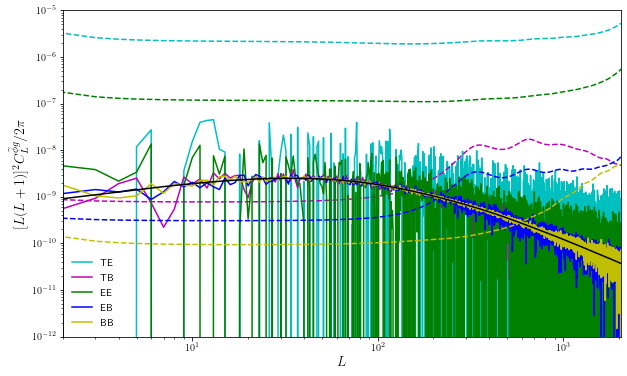

In [12]:
s = (L*(L+1))**2/2/np.pi
pl.plot_1dstyle(usetex=True,fsize=[10,6],xmin=2,xmax=2048,ymin=1e-12,ymax=1e-5,xlog=True,ylog=True,ylab=r'$[L(L+1)]^2 C^{\widetilde{\phi}g}_L/2\pi$')
for qi, (q,c) in enumerate(zip(quad,color)):
    plot(s*Ag[q],color=c,ls='--')
    plot(s*cli[qi],label=q,color=c,ls='-')
plot(s*ucl[3,:]*np.pi/180.,color='k')
legend()
savefig('fig_sim.pdf')